# Day 1 Lab — Build the Research Agent Yourself

Fill in every TODO. Each step tells you exactly **where in the LangGraph docs to look**. Don't open the solution until you've tried each step — the point of Day 1 is learning to **think in state graphs**.

```
START → collect → store_memory → analyze → evaluate
           ↑                                  │
           └── quality < 7 (max 3 tries) ─────┤
                                              └ quality >= 7
                                                    ↓
                                       report → audit → END
```

**Read before you start (~30 min):**
1. [Thinking in LangGraph](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph) — the mental model
2. [Graph API concepts](https://docs.langchain.com/oss/python/langgraph/graph-api) — State, Nodes, Edges
3. [Using the Graph API](https://docs.langchain.com/oss/python/langgraph/use-graph-api) — code patterns you'll copy

API reference: https://reference.langchain.com/python/langgraph/

**Setup:** `uv sync`, then create `.env` (or set `USE_FAKE=1` — see README.md). Launch with `uv run jupyter lab`.

In [17]:
import os
import operator
from datetime import datetime
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage

# TODO STEP 0 — import the graph building blocks from langgraph.
# You need: StateGraph, START, END from langgraph.graph
#           InMemorySaver from langgraph.checkpoint.memory

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


load_dotenv()

True

## STEP 1 — THE STATE  (the "digital clipboard" from the slides)
Define a TypedDict with everything the workflow needs to remember:
  topic (str), search_query (str), collected_data (List[Dict]),
  analyzed_data (List[Dict]), quality_score (int),
  iteration_count (int), final_report (str), execution_logs

KEY IDEA: execution_logs should use a REDUCER so every node can
APPEND log lines instead of overwriting the list:
    execution_logs: Annotated[List[str], operator.add]

WHERE TO LOOK: Graph API docs → "State" section → "Reducers".
  https://docs.langchain.com/oss/python/langgraph/graph-api
ASK YOURSELF: what happens to a plain (non-reducer) key when two
nodes write it? What happens with operator.add?

In [18]:
class AgentState(TypedDict):
    topic: str
    search_query: str
    collected_data: List[Dict]
    analyzed_data: List[Dict]
    quality_score: int
    iteration_count: int
    final_report: str
    execution_logs: Annotated[List[str], operator.add]
    pass 

## STEP 2 — MODEL, SEARCH TOOL, EMBEDDINGS
Create:
  llm          = ChatOpenAI(model="gpt-4o-mini", temperature=0)
  search_tool  = TavilySearch(max_results=5)   # langchain_tavily!
  vector_store = a Chroma or InMemoryVectorStore with embeddings

------------------------------------------------------------
USING OPENROUTER (free models — recommended for this course)
------------------------------------------------------------
OpenRouter is OpenAI-compatible, so ChatOpenAI works as-is —
you only change the key, the base_url, and the model name.

1. Get a key at https://openrouter.ai/keys  (starts with sk-or-)
2. Put in your .env:
       OPENAI_API_KEY=sk-or-...
3. Create the model like this:

   llm = ChatOpenAI(
       model="nvidia/nemotron-3-super-120b-a12b:free",
       temperature=0,
       base_url="https://openrouter.ai/api/v1",
   )

Free NVIDIA Nemotron models (the ":free" suffix is REQUIRED —
without it you'll be billed):
  nvidia/nemotron-3-super-120b-a12b:free   <- use this one
  nvidia/nemotron-3-nano-30b-a3b:free      <- fallback if rate-limited
  nvidia/nemotron-3-ultra-550b-a55b:free   <- biggest, often congested
Full list: https://openrouter.ai/collections/free-models

KNOW THE LIMITS: free models are rate-limited (~20 req/min and a
small daily cap). This lab makes ~5-10 LLM calls per run, so you
have plenty — but don't run it in a tight loop, and if you get
HTTP 429, wait a minute or switch to the nano model.

CAVEAT for Step 3: with_structured_output() needs tool/function
calling. Nemotron supports it, but if a free model ever returns
an error there, either (a) try another :free model, or (b) pass
method="json_schema" to with_structured_output.

NOTE: OpenRouter has NO embeddings endpoint. For the vector store
use InMemoryVectorStore + local HuggingFaceEmbeddings
(uv sync --group embeddings), or DeterministicFakeEmbedding —
embeddings only power the memory-retrieval bonus, not the core graph.
------------------------------------------------------------

GOTCHA: the old imports you'll find in 2023-24 tutorials
(langchain.vectorstores, langchain_community.tools.tavily_search)
are DEAD. Current homes:
  - TavilySearch:      https://docs.langchain.com/oss/python/integrations/providers/tavily
  - Chat models:       https://docs.langchain.com/oss/python/langchain/models
  - InMemoryVectorStore: langchain_core.vectorstores

NOTE: TavilySearch.invoke({"query": q}) returns a DICT — the
actual sources are under the "results" key. print() it once to see.

In [19]:
# TODO: your code here
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.embeddings import DeterministicFakeEmbedding

llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    temperature=0,
    base_url="https://openrouter.ai/api/v1",
)
search_tool = TavilySearch(max_results=5)
vector_store = InMemoryVectorStore(DeterministicFakeEmbedding(size=384))

## STEP 3 — STRUCTURED OUTPUT for the quality score
Never parse int(response.content) out of free text. Define a
Pydantic schema and use llm.with_structured_output(...) so the
model is FORCED to return valid data.

WHERE TO LOOK: https://docs.langchain.com/oss/python/langchain/structured-output
ASK YOURSELF: what does with_structured_output return — a string,
a dict, or a QualityScore object?

In [20]:
class QualityScore(BaseModel):
    """Evaluation of research quality."""
    score: int = Field(ge=1, le=10)
    reasoning: str = Field(description="One-sentence justification")

# TODO: evaluator = llm.with_structured_output(QualityScore)
evaluator = llm.with_structured_output(QualityScore)

## STEP 4 — NODES
A node is just a function: takes state, returns a PARTIAL update
(a dict with ONLY the keys it changed). LangGraph merges it in.
Do NOT mutate state in place; do NOT return the whole state.

WHERE TO LOOK: Use Graph API docs → "Define and update state".
  https://docs.langchain.com/oss/python/langgraph/use-graph-api

In [26]:
'''def collect_node(state: AgentState):
    """Search the web. On retries, CHANGE the query!"""
    # TODO:
    # 1. iteration = state["iteration_count"] + 1
    # 2. Build a query that DIFFERS per iteration (why? see Step 5)
    # 3. results = search_tool.invoke({"query": query})["results"]
    # 4. return {"search_query": ..., "collected_data": ...,
    #            "iteration_count": ..., "execution_logs": [...]}
    pass


def store_memory_node(state: AgentState):
    """Save source contents into the vector store."""
    # TODO: vector_store.add_texts([...contents...])
    pass


def analyze_node(state: AgentState):
    """LLM-analyze each source. Bonus: retrieve related past
    research with vector_store.similarity_search(content, k=2)
    and include it in the prompt — that's what makes this RAG."""
    # TODO
    pass


def evaluate_node(state: AgentState):
    """Score the research with the STRUCTURED evaluator (Step 3)."""
    # TODO: return {"quality_score": result.score, "execution_logs": [...]}
    pass


def report_node(state: AgentState):
    """Generate the enterprise report from analyzed_data."""
    # TODO
    pass


def audit_node(state: AgentState):
    """Log completion stats."""
    # TODO
    pass'''

def collect_node(state: AgentState):
    """Search the web. On retries, CHANGE the query!"""
    iteration = state["iteration_count"] + 1
    topic = state["topic"]

    # A different angle each pass, so a retry doesn't re-fetch the same page
    angles = [
        f"{topic} overview",
        f"{topic} technical details implementation 2025",
        f"{topic} case studies benchmarks limitations",
    ]
    query = angles[min(iteration - 1, len(angles) - 1)]

    results = search_tool.invoke({"query": query})["results"]
    collected = [
        {
            "title": r.get("title", ""),
            "url": r.get("url", ""),
            "content": r.get("content", ""),
        }
        for r in results
    ]

    return {
        "search_query": query,
        "collected_data": collected,
        "iteration_count": iteration,
        "execution_logs": [
            f"[collect] iter={iteration} query='{query}' -> {len(collected)} results"
        ],
    }


def store_memory_node(state: AgentState):
    """Save source contents into the vector store."""
    texts = [d["content"] for d in state["collected_data"] if d.get("content")]
    metadatas = [
        {"url": d.get("url", ""), "title": d.get("title", "")}
        for d in state["collected_data"]
        if d.get("content")
    ]
    if texts:
        vector_store.add_texts(texts, metadatas=metadatas)
    return {"execution_logs": [f"[store_memory] stored {len(texts)} docs"]}


def analyze_node(state: AgentState):
    """LLM-analyze each source, grounded in related past research (RAG)."""
    analyzed = []
    for d in state["collected_data"]:
        content = d.get("content", "")
        if not content:
            continue

        # Retrieval step: pull related prior research from memory
        related = vector_store.similarity_search(content, k=2)
        context = "\n---\n".join(doc.page_content for doc in related) or "None."

        prompt = f"""You are a research analyst. Analyze this source about: {state['topic']}

SOURCE ({d.get('title','untitled')} — {d.get('url','')}):
{content[:3000]}

RELATED PRIOR RESEARCH FROM MEMORY:
{context[:2000]}

Return 3-5 bullet points: key facts, figures, and how this confirms or contradicts the prior research."""

        analysis = llm.invoke(prompt).content
        analyzed.append({
            "title": d.get("title", ""),
            "url": d.get("url", ""),
            "analysis": analysis,
        })

    return {
        "analyzed_data": analyzed,
        "execution_logs": [f"[analyze] analyzed {len(analyzed)} sources with RAG context"],
    }


def evaluate_node(state: AgentState):
    """Score the research with the STRUCTURED evaluator (Step 3)."""
    summary = "\n\n".join(
        f"{a['title']} ({a['url']})\n{a['analysis']}" for a in state["analyzed_data"]
    )
    result = evaluator.invoke(
        f"Research topic: {state['topic']}\n\nFindings:\n{summary}"
    )
    return {
        "quality_score": result.score,
        "execution_logs": [f"[evaluate] score={result.score} feedback={result.reasoning}"],
    }


def report_node(state: AgentState):
    """Generate the enterprise report from analyzed_data."""
    findings = "\n\n".join(
        f"### {a['title']}\nSource: {a['url']}\n{a['analysis']}"
        for a in state["analyzed_data"]
    )
    prompt = f"""Write an enterprise research report on: {state['topic']}

Use ONLY these analyzed findings:
{findings}

Structure:
# Executive Summary (3-4 sentences)
# Key Findings (bulleted)
# Analysis
# Risks & Limitations
# Recommendations
# Sources (markdown links)"""

    report = llm.invoke(prompt).content
    return {
        "final_report": report,
        "execution_logs": [f"[report] generated report ({len(report)} chars)"],
    }


def audit_node(state: AgentState):
    """Log completion stats."""
    return {
        "execution_logs": [
            "[audit] COMPLETE | "
            f"iterations={state['iteration_count']} | "
            f"sources={len(state['collected_data'])} | "
            f"analyzed={len(state['analyzed_data'])} | "
            f"quality={state['quality_score']} | "
            f"report={'yes' if state.get('final_report') else 'no'}"
        ]
    }

#======================================================

'def collect_node(state: AgentState):\n    iteration = state["iteration_count"] + 1\n    angles = [\n        f"{state[\'topic\']} overview and core concepts",\n        f"{state[\'topic\']} enterprise case studies and architectures",\n        f"{state[\'topic\']} risks, governance and evaluation benchmarks",\n    ]\n    query = angles[min(iteration - 1, len(angles) - 1)]\n    results = search_tool.invoke({"query": query})["results"]\n    return {\n        "search_query": query,\n        "collected_data": results,\n        "iteration_count": iteration,\n        "execution_logs": [f"[collect] iter={iteration} \'{query}\' → {len(results)} sources"],\n    }\n\n\ndef store_memory_node(state: AgentState):\n    texts = [d["content"] for d in state["collected_data"] if d.get("content")]\n    if texts:\n        vector_store.add_texts(texts)\n    return {"execution_logs": [f"[store_memory] stored {len(texts)} docs"]}\n\n\ndef analyze_node(state: AgentState):\n    analyzed = []\n    for source in 

## STEP 5 — THE CONDITIONAL EDGE (the heart of this lab)
Write a router function: takes state, RETURNS THE NAME of the
next node as a string.

CRITICAL — loops must terminate. Two rules:
  a) every retry must change something (your query, Step 4.2),
  b) hard-cap the retries with iteration_count.
Without both, same search → same score → infinite loop → LangGraph
kills the run at recursion limit 25 with GraphRecursionError.

WHERE TO LOOK (read BOTH):
  - "Conditional branching":
    https://docs.langchain.com/oss/python/langgraph/use-graph-api#conditional-branching
  - "Create and control loops":
    https://docs.langchain.com/oss/python/langgraph/use-graph-api#create-and-control-loops

EXPERIMENT: comment out the iteration cap, force low scores, run,
and read the GraphRecursionError message. Now you understand why
the docs insist on termination conditions.

In [27]:
def quality_router(state: AgentState) -> str:
    # TODO: return "report" or "collect"
    if state["quality_score"] >= 7:
        return "report"
    if state["iteration_count"] >= 3:
        return "report"
    return "collect"

## STEP 6 — WIRE THE GRAPH
1. workflow = StateGraph(AgentState)
2. add_node(...) for all six nodes
3. add_edge(START, "collect")        <- START, not set_entry_point
4. linear edges: collect → store_memory → analyze → evaluate
5. add_conditional_edges("evaluate", quality_router,
       {"collect": "collect", "report": "report"})
   (the dict maps router RETURN VALUES to NODE NAMES)
6. report → audit → END

WHERE TO LOOK: Graph API docs → "Edges".

In [28]:
# TODO: your code here
workflow = StateGraph(AgentState)

workflow.add_node("collect", collect_node)
workflow.add_node("store_memory", store_memory_node)
workflow.add_node("analyze", analyze_node)
workflow.add_node("evaluate", evaluate_node)
workflow.add_node("report", report_node)
workflow.add_node("audit", audit_node)

workflow.add_edge(START, "collect")
workflow.add_edge("collect", "store_memory")
workflow.add_edge("store_memory", "analyze")
workflow.add_edge("analyze", "evaluate")
workflow.add_conditional_edges(
    "evaluate", quality_router, {"collect": "collect", "report": "report"}
)
workflow.add_edge("report", "audit")
workflow.add_edge("audit", END)

## STEP 7 — COMPILE with a checkpointer, VISUALIZE, RUN
1. app = workflow.compile(checkpointer=InMemorySaver())
   A checkpointer saves state after every node → enables resume,
   time-travel debugging, and human-in-the-loop.
   WHERE TO LOOK: https://docs.langchain.com/oss/python/langgraph/persistence

2. Visualize what you built:
      print(app.get_graph().draw_mermaid())
   → paste the output into https://mermaid.live
   Does the picture match the diagram at the top of this file?

3. Run with STREAMING so you watch state evolve node by node:
      config = {"configurable": {"thread_id": "run-1"}}  # required
      for chunk in app.stream(initial_state, config,
                              stream_mode="values"):
          ...
   WHERE TO LOOK: https://docs.langchain.com/oss/python/langgraph/streaming

4. BONUS — human-in-the-loop: compile with
      interrupt_before=["report"]
   then inspect state and resume. WHERE TO LOOK:
      https://docs.langchain.com/oss/python/langgraph/interrupts

In [29]:
initial_state = {
    "topic": "Enterprise Agentic AI Systems",
    "search_query": "",
    "collected_data": [],
    "analyzed_data": [],
    "quality_score": 0,
    "iteration_count": 0,
    "final_report": "",
    "execution_logs": [],
}
# TODO: compile, visualize, stream, print final report + logs
app = workflow.compile(checkpointer=InMemorySaver())
print(app.get_graph().draw_mermaid())

config = {"configurable": {"thread_id": "run-1"}}
final_state = None
for chunk in app.stream(initial_state, config, stream_mode="values"):
    final_state = chunk
    if chunk.get("execution_logs"):
        print(chunk["execution_logs"][-1])

print(final_state["final_report"])
for line in final_state["execution_logs"]:
    print(line)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	collect(collect)
	store_memory(store_memory)
	analyze(analyze)
	evaluate(evaluate)
	report(report)
	audit(audit)
	__end__([<p>__end__</p>]):::last
	__start__ --> collect;
	analyze --> evaluate;
	collect --> store_memory;
	evaluate -.-> collect;
	evaluate -.-> report;
	report --> audit;
	store_memory --> analyze;
	audit --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

[collect] iter=1 query='Enterprise Agentic AI Systems overview' -> 5 results
[store_memory] stored 5 docs
[analyze] analyzed 5 sources with RAG context
[evaluate] score=10 feedback=All sources consistently confirm the core definition, architectural pillars (memory, reasoning, orchestration), design patterns (Multi-Agent, Tool-Use, Planning, Reflection), operational benefits (reduced hallucinations, improved predictability, incident-response automation), and 

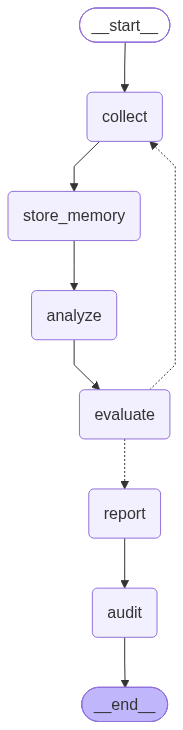

In [32]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## SELF-CHECK before you look at the solution
[ ] My nodes return partial dicts, never the whole mutated state
[ ] execution_logs uses a reducer, and I can explain why
[ ] My router has BOTH a quality exit AND an iteration cap
[ ] Retried searches use a different query than the first attempt
[ ] I saw the Mermaid diagram and it matches the intended flow
[ ] I know what GraphRecursionError is and how to trigger it
[ ] The quality score comes from with_structured_output, not int()

Stuck? Debugging order that works:
  1. print() the raw return of search_tool.invoke — check its shape
  2. run app.stream(..., stream_mode="updates") — shows exactly
     which node produced which state update
  3. compare your edge wiring against the diagram at the top
  4. only THEN open day1_lab_solution.py